In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
orders = pd.read_csv("../data/processed/orders_features.csv")

In [4]:
orders.shape

(99441, 18)

In [5]:
orders.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_days',
 'delivery_delay_days',
 'total_order_value',
 'delivery_status',
 'customer_order_count',
 'customer_total_spending',
 'average_order_value',
 'repeat_customer',
 'customer_unique_id',
 'customer_unique_order_count']

In [6]:
order_status_counts = orders["order_status"].value_counts()

order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [7]:
order_status_percentage = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

order_status_percentage

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

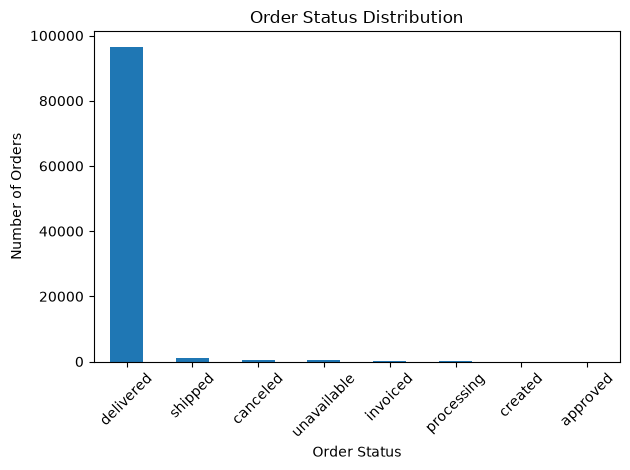

In [8]:
order_status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
orders["total_order_value"].describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: total_order_value, dtype: float64

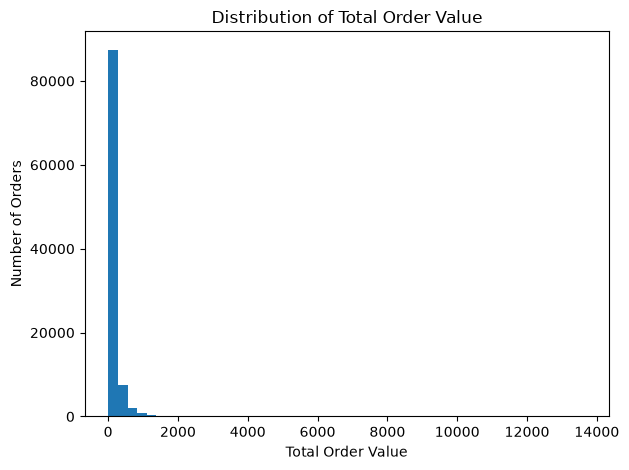

In [10]:
orders["total_order_value"].plot(
    kind="hist",
    bins=50
)

plt.title("Distribution of Total Order Value")
plt.xlabel("Total Order Value")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [11]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [12]:
orders["order_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [13]:
monthly_orders = (
    orders
    .groupby("order_month")["order_id"]
    .count()
)

monthly_orders

order_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

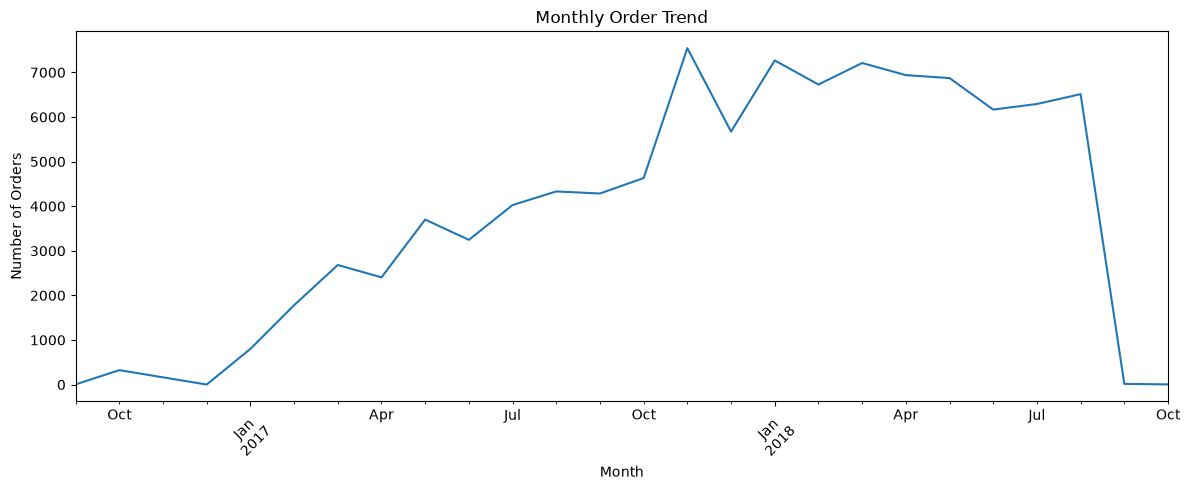

In [14]:
monthly_orders.plot(
    kind="line",
    figsize=(12, 5)
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
monthly_sales = (
    orders
    .groupby("order_month")["total_order_value"]
    .sum(min_count=1)
)

In [16]:
monthly_sales

order_month
2016-09        354.75
2016-10      56808.84
2016-12         19.62
2017-01     137188.49
2017-02     286280.62
2017-03     432048.59
2017-04     412422.24
2017-05     586190.95
2017-06     502963.04
2017-07     584971.62
2017-08     668204.60
2017-09     720398.91
2017-10     769312.37
2017-11    1179143.77
2017-12     863547.23
2018-01    1107301.89
2018-02     986908.96
2018-03    1155126.82
2018-04    1159698.04
2018-05    1149781.82
2018-06    1022677.11
2018-07    1058728.03
2018-08    1003308.47
2018-09        166.46
2018-10           NaN
Freq: M, Name: total_order_value, dtype: float64

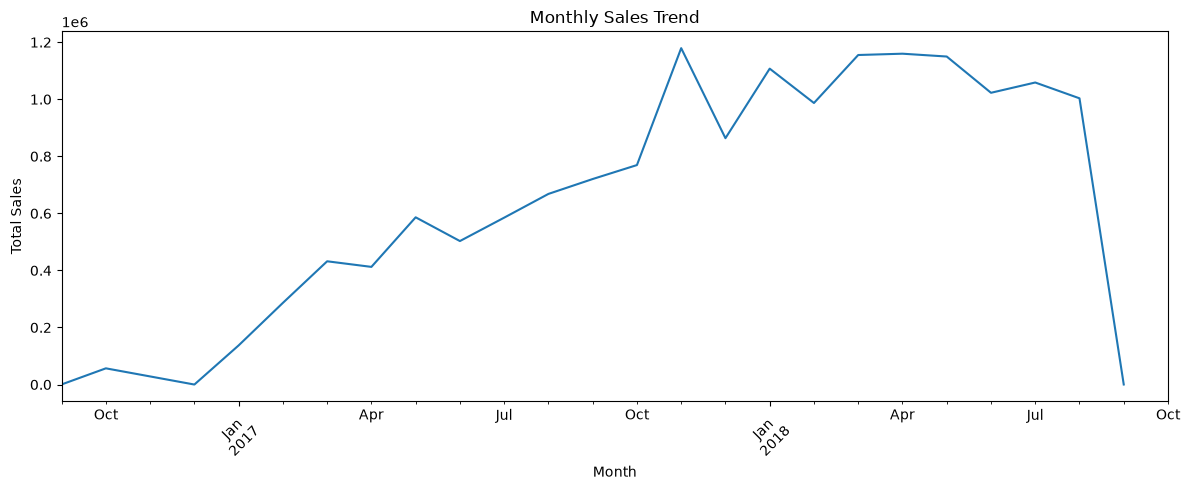

In [17]:
monthly_sales.plot(
    kind="line",
    figsize=(12, 5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
customer_type_counts = orders["repeat_customer"].value_counts()

customer_type_counts

repeat_customer
False    93099
True      6342
Name: count, dtype: int64

In [20]:
customer_type_counts.index = customer_type_counts.index.map({
    False: "New Customer",
    True: "Repeat Customer"
})

customer_type_counts

repeat_customer
New Customer       93099
Repeat Customer     6342
Name: count, dtype: int64

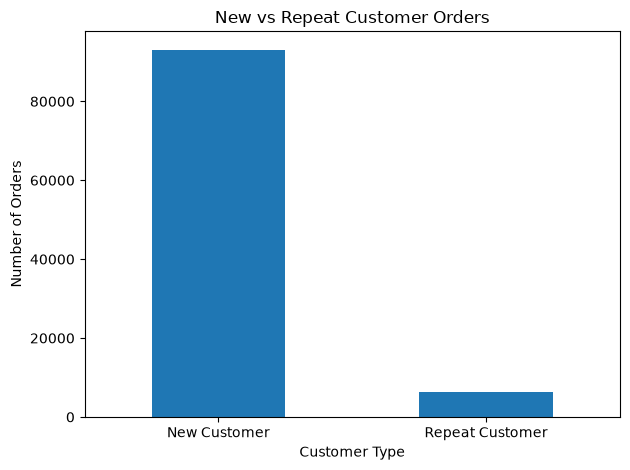

In [21]:
customer_type_counts.plot(
    kind="bar"
)

plt.title("New vs Repeat Customer Orders")
plt.xlabel("Customer Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
orders["customer_total_spending"].describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: customer_total_spending, dtype: float64

In [23]:
orders["average_order_value"].describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: average_order_value, dtype: float64

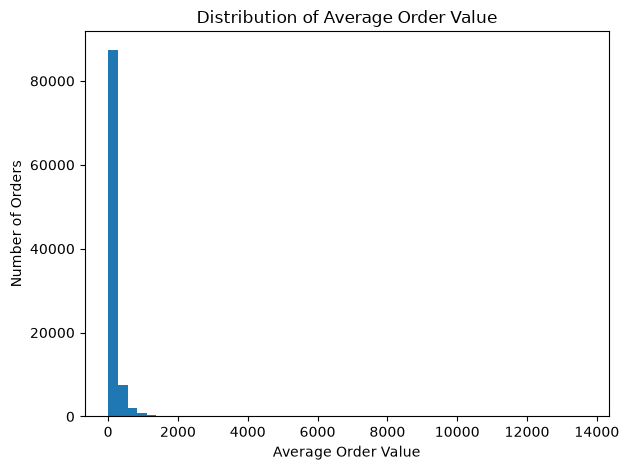

In [24]:
orders["average_order_value"].plot(
    kind="hist",
    bins=50
)

plt.title("Distribution of Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [25]:
delivery_status_counts = orders["delivery_status"].value_counts()

delivery_status_counts

delivery_status
On Time          88649
Delayed           7827
Not Delivered     2965
Name: count, dtype: int64

In [26]:
delivery_status_percentage = (
    orders["delivery_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

delivery_status_percentage

delivery_status
On Time          89.15
Delayed           7.87
Not Delivered     2.98
Name: proportion, dtype: float64

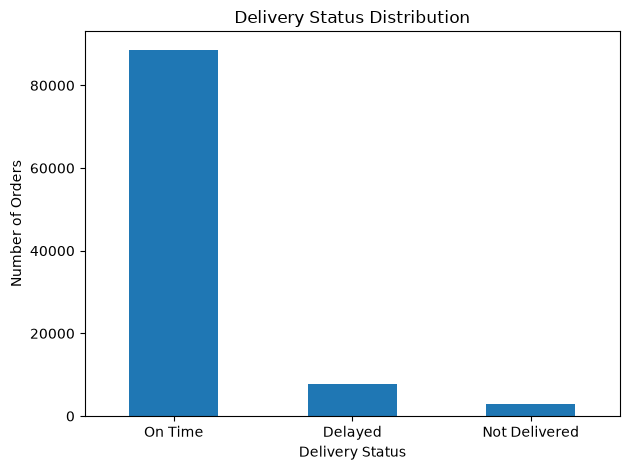

In [27]:
delivery_status_counts.plot(
    kind="bar"
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

In [30]:
orders["delivery_delay_days"].describe()

count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_delay_days, dtype: float64

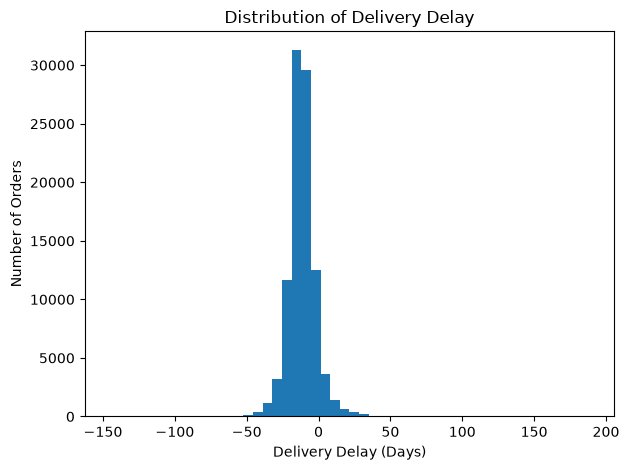

In [31]:
orders["delivery_delay_days"].plot(
    kind="hist",
    bins=50
)

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [32]:
delayed_orders = orders[
    orders["delivery_delay_days"] > 0
]

delayed_orders["delivery_delay_days"].describe()

count    7827.000000
mean        9.552206
std        13.951700
min         0.002500
25%         1.867193
50%         5.807894
75%        11.822471
max       188.975081
Name: delivery_delay_days, dtype: float64

In [33]:
sellers = pd.read_csv(
    "../data/processed/sellers_features.csv"
)

In [34]:
sellers.shape

(3095, 6)

In [35]:
sellers["seller_revenue"].describe()

count      3095.000000
mean       4391.484233
std       13921.997192
min           3.500000
25%         208.850000
50%         821.480000
75%        3280.830000
max      229472.630000
Name: seller_revenue, dtype: float64

In [36]:
top_sellers_revenue = (
    sellers
    .sort_values("seller_revenue", ascending=False)
    .head(10)
)

top_sellers_revenue[
    ["seller_id", "seller_city", "seller_state", "seller_revenue"]
]

,seller_id,seller_city,seller_state,seller_revenue
2617,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,229472.63
901,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,222776.05
2463,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,200472.92
557,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,194042.03
1182,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,187923.89
68,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,176431.87
1873,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,160236.57
2207,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,141745.53
2720,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,138968.55
390,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,135171.70


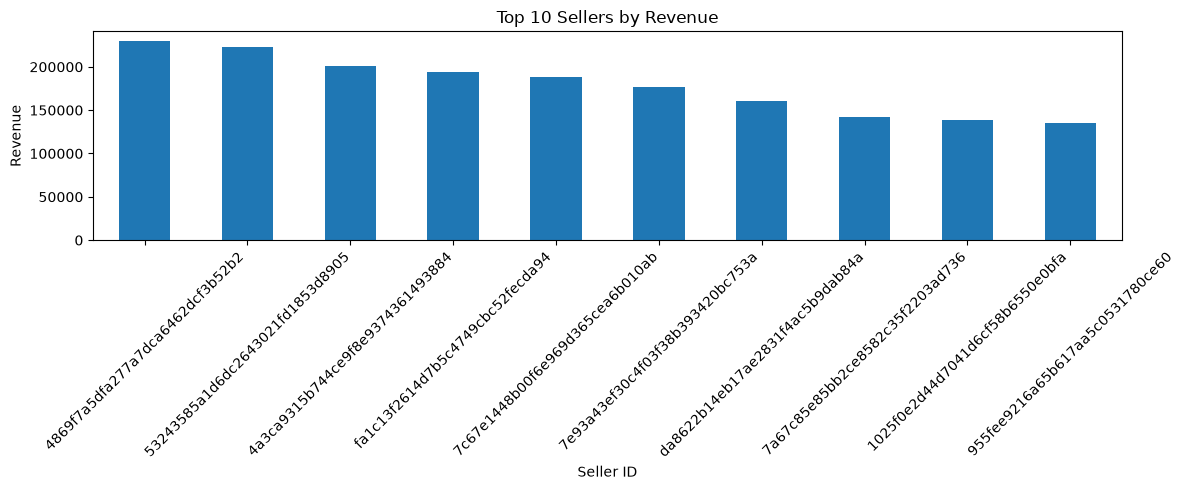

In [37]:
top_sellers_revenue.plot(
    x="seller_id",
    y="seller_revenue",
    kind="bar",
    figsize=(12, 5),
    legend=False
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
top_sellers_orders = (
    sellers
    .sort_values("seller_order_count", ascending=False)
    .head(10)
)

top_sellers_orders[
    ["seller_id", "seller_city", "seller_state", "seller_order_count"]
]

,seller_id,seller_city,seller_state,seller_order_count
797,6560211a19b47992c3666cc44a7e94c0,sao paulo,SP,1854
2463,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,1806
1413,cc419e0650a3c5ba77189a1882b7556a,santo andre,SP,1706
474,1f50f920176fa81dab994f9023523100,sao jose do rio preto,SP,1404
1873,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,1314
390,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,1287
2207,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,1160
987,ea8482cd71df3c1969d7b9473ff13abc,sao paulo,SP,1146
2617,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1132
2345,3d871de0142ce09b7081e2b9d1733cb1,campo limpo paulista,SP,1080


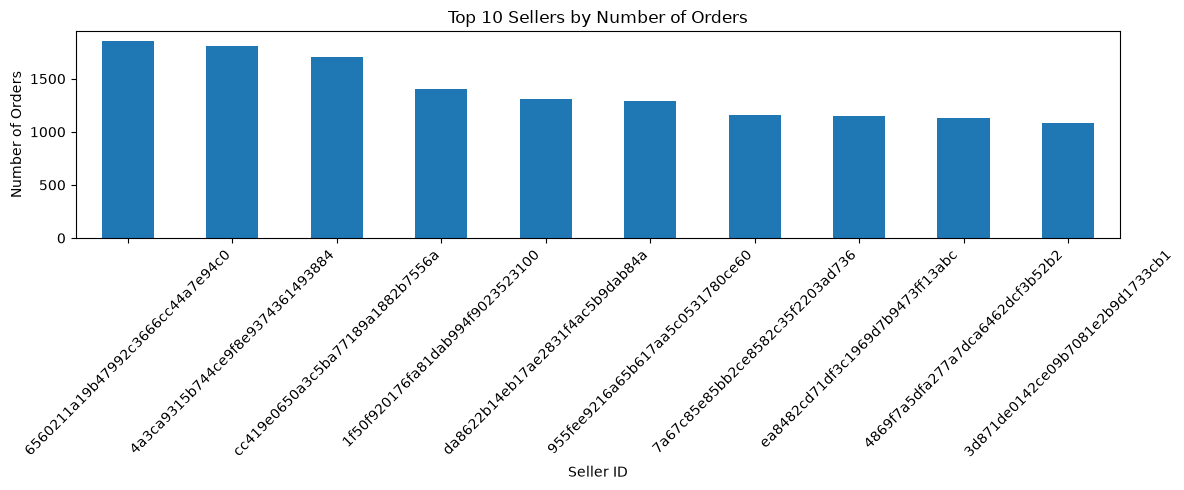

In [39]:
top_sellers_orders.plot(
    x="seller_id",
    y="seller_order_count",
    kind="bar",
    figsize=(12, 5),
    legend=False
)

plt.title("Top 10 Sellers by Number of Orders")
plt.xlabel("Seller ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
seller_state_counts = (
    sellers["seller_state"]
    .value_counts()
)

seller_state_counts

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

In [41]:
top_seller_states = seller_state_counts.head(10)

top_seller_states

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64

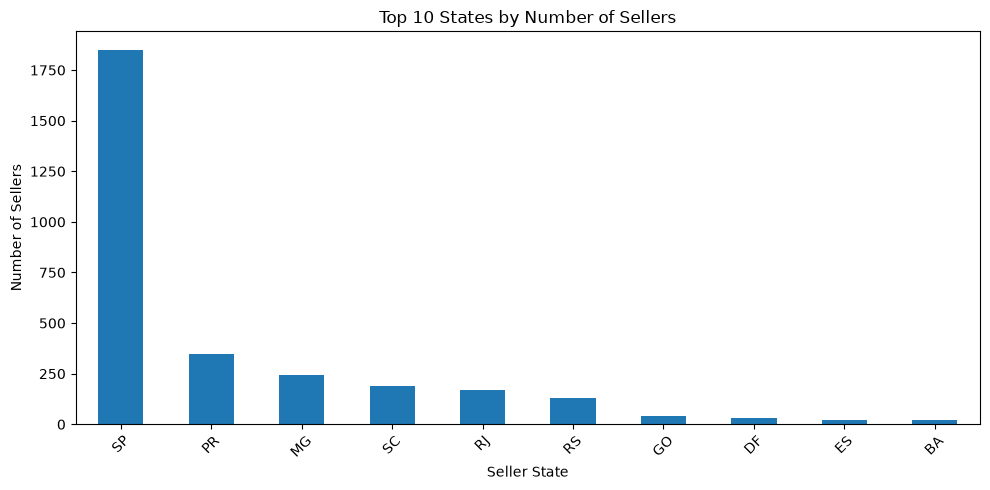

In [42]:
top_seller_states.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 States by Number of Sellers")
plt.xlabel("Seller State")
plt.ylabel("Number of Sellers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
customer_frequency = (
    orders[
        ["customer_unique_id", "customer_unique_order_count"]
    ]
    .drop_duplicates("customer_unique_id")
)

In [44]:
customer_frequency["customer_unique_order_count"].value_counts().sort_index()

customer_unique_order_count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

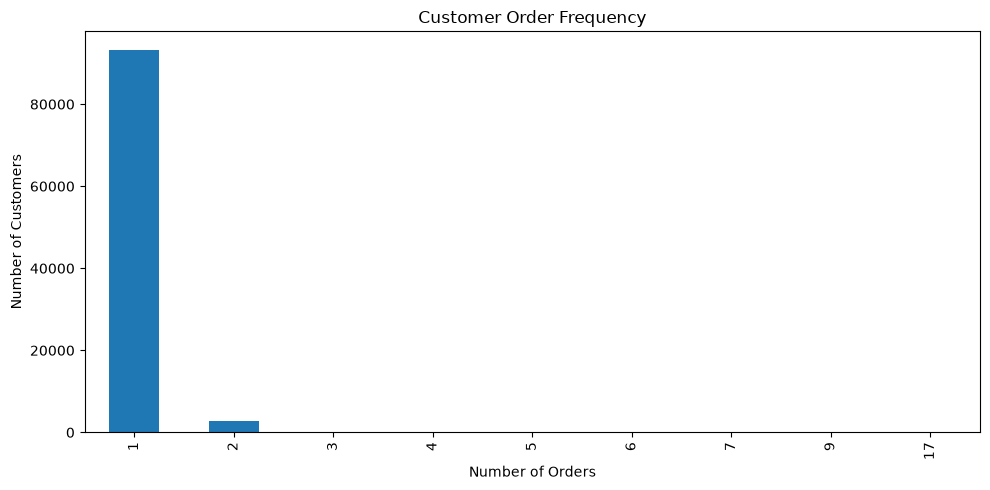

In [45]:
customer_frequency["customer_unique_order_count"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Customer Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [46]:
delivery_order_status = pd.crosstab(
    orders["order_status"],
    orders["delivery_status"]
)

delivery_order_status

delivery_status,Delayed,Not Delivered,On Time
order_status,,,
approved,0,2,0
canceled,1,619,5
created,0,5,0
delivered,7826,8,88644
invoiced,0,314,0
processing,0,301,0
shipped,0,1107,0
unavailable,0,609,0


In [47]:
delivery_order_status_pct = pd.crosstab(
    orders["order_status"],
    orders["delivery_status"],
    normalize="index"
).mul(100).round(2)

delivery_order_status_pct

delivery_status,Delayed,Not Delivered,On Time
order_status,,,
approved,0.00,100.00,0.00
canceled,0.16,99.04,0.80
created,0.00,100.00,0.00
delivered,8.11,0.01,91.88
invoiced,0.00,100.00,0.00
processing,0.00,100.00,0.00
shipped,0.00,100.00,0.00
unavailable,0.00,100.00,0.00


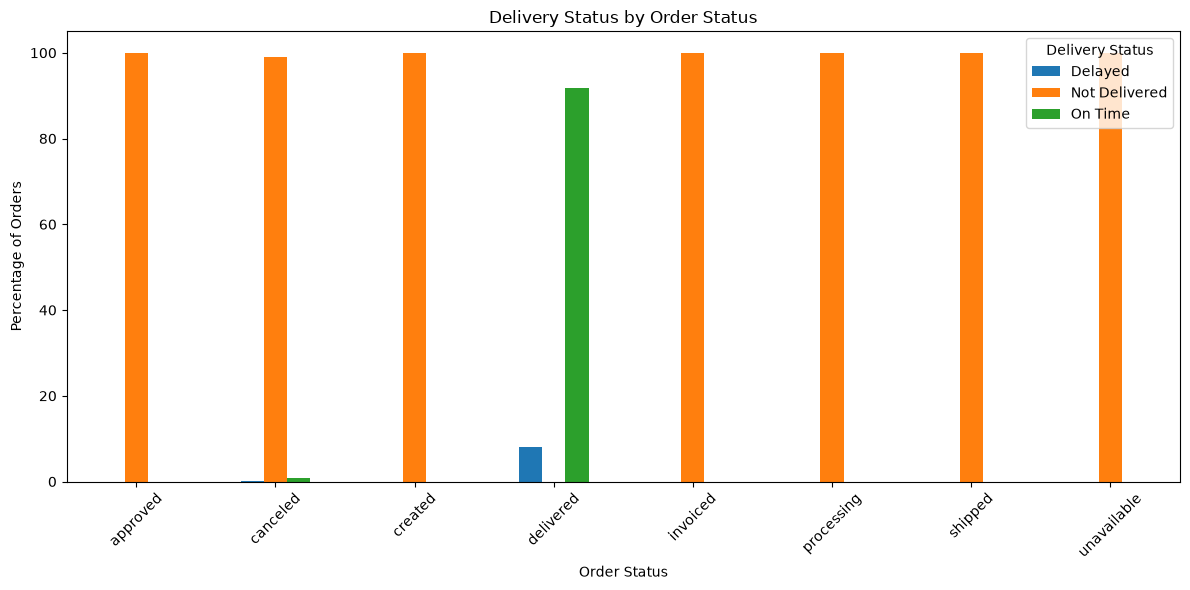

In [48]:
delivery_order_status_pct.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Delivery Status by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Percentage of Orders")
plt.xticks(rotation=45)
plt.legend(title="Delivery Status")
plt.tight_layout()
plt.show()

In [49]:
eda_numeric_summary = orders[
    [
        "total_order_value",
        "delivery_days",
        "delivery_delay_days",
        "customer_order_count",
        "customer_total_spending",
        "average_order_value",
        "customer_unique_order_count"
    ]
].describe()

eda_numeric_summary

,total_order_value,delivery_days,delivery_delay_days,customer_order_count,customer_total_spending,average_order_value,customer_unique_order_count
count,98666.000000,96476.000000,96476.000000,99441.0,98666.000000,98666.000000,99441.000000
mean,160.577638,12.558702,-11.179120,1.0,160.577638,160.577638,1.079223
std,220.466087,9.546530,10.186113,0.0,220.466087,220.466087,0.396154
min,9.590000,0.533414,-146.016123,1.0,9.590000,9.590000,1.000000
25%,61.980000,6.766403,-16.244384,1.0,61.980000,61.980000,1.000000
50%,105.290000,10.217755,-11.948941,1.0,105.290000,105.290000,1.000000
75%,176.870000,15.720327,-6.390000,1.0,176.870000,176.870000,1.000000
max,13664.080000,209.628611,188.975081,1.0,13664.080000,13664.080000,17.000000


In [50]:
orders[
    [
        "total_order_value",
        "delivery_days",
        "delivery_delay_days",
        "customer_order_count",
        "customer_total_spending",
        "average_order_value",
        "customer_unique_order_count"
    ]
].isna().sum()

total_order_value               775
delivery_days                  2965
delivery_delay_days            2965
customer_order_count              0
customer_total_spending         775
average_order_value             775
customer_unique_order_count       0
dtype: int64

In [51]:
print("Order Status:")
print(orders["order_status"].value_counts())

print("\nDelivery Status:")
print(orders["delivery_status"].value_counts())

print("\nRepeat Customer:")
print(orders["repeat_customer"].value_counts())

Order Status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Delivery Status:
delivery_status
On Time          88649
Delayed           7827
Not Delivered     2965
Name: count, dtype: int64

Repeat Customer:
repeat_customer
False    93099
True      6342
Name: count, dtype: int64


In [52]:
import pandas as pd
import scipy.stats as stats

order_reviews = pd.read_csv(
    "../data/cleaned/order_reviews_clean.csv"
)

order_payments = pd.read_csv(
    "../data/cleaned/order_payments_clean.csv"
)

order_items = pd.read_csv(
    "../data/cleaned/order_items_clean.csv"
)

products = pd.read_csv(
    "../data/cleaned/products_clean.csv"
)

category_translation = pd.read_csv(
    "../data/cleaned/category_translation_clean.csv"
)

In [53]:
print("order_reviews:")
print(order_reviews.columns.tolist())

print("\norder_payments:")
print(order_payments.columns.tolist())

print("\norder_items:")
print(order_items.columns.tolist())

print("\nproducts:")
print(products.columns.tolist())

print("\ncategory_translation:")
print(category_translation.columns.tolist())

order_reviews:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

order_payments:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

order_items:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

products:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

category_translation:
['product_category_name', 'product_category_name_english']


In [54]:
review_delivery = order_reviews.merge(
    orders[["order_id", "delivery_status"]],
    on="order_id",
    how="inner"
)

In [55]:
review_delivery["delivery_status"].value_counts()

delivery_status
On Time          88658
Delayed           7701
Not Delivered     2865
Name: count, dtype: int64

In [56]:
review_delivery_test = review_delivery[
    review_delivery["delivery_status"].isin(
        ["On Time", "Delayed"]
    )
].copy()

In [57]:
review_delivery_test["delivery_status"].value_counts()

delivery_status
On Time    88658
Delayed     7701
Name: count, dtype: int64

In [58]:
on_time_scores = review_delivery_test.loc[
    review_delivery_test["delivery_status"] == "On Time",
    "review_score"
].dropna()

delayed_scores = review_delivery_test.loc[
    review_delivery_test["delivery_status"] == "Delayed",
    "review_score"
].dropna()

In [59]:
print("On Time reviews:", len(on_time_scores))
print("Delayed reviews:", len(delayed_scores))

On Time reviews: 88658
Delayed reviews: 7701


In [60]:
t_stat, p_value = stats.ttest_ind(
    on_time_scores,
    delayed_scores,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 89.55081413351807
P-value: 0.0


In [61]:
print("On Time mean review score:", on_time_scores.mean())
print("Delayed mean review score:", delayed_scores.mean())

On Time mean review score: 4.293577567732184
Delayed mean review score: 2.566549798727438


In [62]:
t_stat, p_value = stats.ttest_ind(
    on_time_scores,
    delayed_scores,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 89.55081413351807
P-value: 0.0


In [63]:
# Merge order items with product category
anova_data = order_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

# Add English category names
anova_data = anova_data.merge(
    category_translation[
        ["product_category_name", "product_category_name_english"]
    ],
    on="product_category_name",
    how="left"
)

anova_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


In [64]:
print("Rows:", len(anova_data))
print("Missing category:", anova_data["product_category_name"].isna().sum())
print("Missing price:", anova_data["price"].isna().sum())

Rows: 112650
Missing category: 1603
Missing price: 0


In [65]:
# Use English category where available
anova_data["category"] = anova_data[
    "product_category_name_english"
].fillna(anova_data["product_category_name"])

# Keep only rows with a category and price
anova_clean = anova_data[
    ["category", "price"]
].dropna()

print("Rows used for ANOVA:", len(anova_clean))
print("Number of categories:", anova_clean["category"].nunique())

Rows used for ANOVA: 111047
Number of categories: 73


In [66]:
# Check observations per category
category_counts = anova_clean["category"].value_counts()

print(category_counts.head(10))
print("Categories with fewer than 2 observations:",
      (category_counts < 2).sum())

category
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64
Categories with fewer than 2 observations: 0


In [67]:
print("Categories with fewer than 2 observations:",
      (category_counts < 2).sum())

Categories with fewer than 2 observations: 0


In [68]:
f_stat, p_value = stats.f_oneway(
    *[
        group["price"].values
        for _, group in anova_clean.groupby("category")
    ]
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 192.0054163328106
P-value: 0.0


In [69]:
primary_payment = (
    order_payments
    .sort_values(["order_id", "payment_sequential"])
    .drop_duplicates("order_id")
    [["order_id", "payment_type"]]
)

payment_status = primary_payment.merge(
    orders[["order_id", "order_status"]],
    on="order_id",
    how="inner"
)

payment_status.head()

,order_id,payment_type,order_status
0,00010242fe8c5a6d1ba2dd792cb16214,credit_card,delivered
1,00018f77f2f0320c557190d7a144bdd3,credit_card,delivered
2,000229ec398224ef6ca0657da4fc703e,credit_card,delivered
3,00024acbcdf0a6daa1e931b038114c75,credit_card,delivered
4,00042b26cf59d7ce69dfabb4e55b4fd9,credit_card,delivered


In [70]:
contingency_table = pd.crosstab(
    payment_status["payment_type"],
    payment_status["order_status"]
)

print(contingency_table)

order_status  approved  canceled  created  delivered  invoiced  processing  \
payment_type                                                                 
boleto               0        95        2      19191        67          70   
credit_card          2       444        3      74303       239         222   
debit_card           0         7        0       1485         6           2   
not_defined          0         3        0          0         0           0   
voucher              0        76        0       1498         2           7   

order_status  shipped  unavailable  
payment_type                        
boleto            209          150  
credit_card       848          443  
debit_card         22            6  
not_defined         0            0  
voucher            28           10  


In [71]:
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 939.509784002784
P-value: 8.714660119444278e-180
Degrees of freedom: 28
